# Allen-Cahn PDE

## Domain Incremental Learning

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments location

**AllenCahn**

- **DomainIncrementalLearning**
    - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
        - **Forget** | 
            - **FromScratch** | **FineTune** (*)
        - **Replay** | **Distill** | **Distill_EWC**
            - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
                - **FromScratch** | **FineTune** (*)
        - **EWC**
            - **FromScratch** | **FineTune** (*)
    - **Dom0**
        - **models0** | ... | **modelsM**
            - **tiral0** | ... | **trialN**
                - model.pth, training stats files

(*):
- **Dom1** | ... | **DomD**
    - **models**
        - **trial0**
            - model.pth, training stats files

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from data_utils import extract_TensorDataset, compute_prediction_difference, compute_prediction, extract_targets, extract_boundary
from plot_utils import plot_loss, plot_loss_comp, plot_model_stats, print_model_info, plot_model_stats_grid, print_model_performances, plot_model_performances, plot_performance_comparison
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from generate import X, U, DU, D2U
# ----------------------------------------------
TRAIN = False
SAVE_PLOTS = True
CROSS_THE_RUBICON = True

PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"
SEED = 42
PARAM_INDEX = None # if None, all tasks are considered
ACTUAL_MODE = "PINN"

MEMORY_AS_ACTUAL_TRAIN_SIZE = False
MEMORY_DISTILL = 1024 # 1024 None
MEMORY_REPLAY_SUPERVISED = None # 1024 None
MEMORY_REPLAY = 1024 # 1024 None
MEMORY_EWC = 1024 # 1024 None

LONG_TERM_MEMORY = True
FINE_TUNING = True

#N_SAMPLES = 256
ACTION = "Distill" # "Forget" "Replay" "Distill" "EWC"
REPLAY_MODE = "Residual+Boundary" #"Residual" "Boundary" "Residual+Boundary" "Derivative+Output" "Output" "Derivative" "Hessian"
DISTILL_MODE = "Output+Derivative" #"Output" "Derivative" "Hessian"
EWC_WEIGHT = 10000000.0
EWC_ALPHA = 1.0

EWC_AUTO_WEIGHTING = False
EWC_WARM_UP = 1
EWC_DECAY = 1.0

N_EPOCHS = 200
N_EPOCHS_DOM0 = 200

SMALL_LR = False
LR_MODE = "CosAnn"
BD_MODE = "LocalFull" #LocalFull Global
DWA_MODE = "Norm1"
CLIP_GRAD = True
# ----------------------------------------------
if LR_MODE == "ExpDec":
    LR = "_ExpLrDecay"
else:
    LR_MODE = "CosAnn"
    LR = "_CosLrAnnealing"

if LONG_TERM_MEMORY:
    MEMORY = "LongMemory"
else:
    MEMORY = "ShortMemory"
if ACTION == "Forget":
    MEMORY = ""
if PARAM_INDEX is None:
    DIR = "MultiTask"
    BATCH_SIZE_TRAIN = 1024
    BATCH_SIZE_DEV = 1024
else:
    DIR = f"Task{PARAM_INDEX}"
    BATCH_SIZE_TRAIN = 512
    BATCH_SIZE_DEV = 512

if ACTION == "Replay":
    DISTILL_MODE = REPLAY_MODE
    
FROM_SCRATCH = not FINE_TUNING

if FINE_TUNING:
    MODE = "FineTune"
else:
    MODE = "FromScratch"

if SMALL_LR:
    LR_SIZE = "SmallLR"
else:
    LR_SIZE = ""

if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

FORGET, REPLAY, DISTILL, EWC = False, False, False, False
if ACTION == "Forget":
    FORGET = True
    FOLDER = f"Forget/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
elif ACTION == "Replay":
    REPLAY = True
    FOLDER = f"Replay/{DISTILL_MODE}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if MEMORY_AS_ACTUAL_TRAIN_SIZE:
        FOLDER = "LimitedMemory1/" + FOLDER
    elif ("Residual" in REPLAY_MODE and MEMORY_REPLAY is None) or \
        ("Boundary" in REPLAY_MODE and MEMORY_REPLAY is None) or \
        ("Output" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None) or \
        ("Derivative" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None) or \
        ("Hessian" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None):
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER
elif ACTION == "Distill":
    DISTILL = True
    FOLDER = f"Distill/{DISTILL_MODE}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if MEMORY_AS_ACTUAL_TRAIN_SIZE:
        FOLDER = "LimitedMemory1/" + FOLDER
    elif MEMORY_DISTILL is None:
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER
elif ACTION == "EWC":
    EWC = True
    if EWC_AUTO_WEIGHTING:
        FOLDER = f"EWC/alpha_{EWC_ALPHA}/weight_auto/warmup{EWC_WARM_UP}_decay{EWC_DECAY}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    else:
        FOLDER = f"EWC/alpha_{EWC_ALPHA}/weight_{EWC_WEIGHT}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if MEMORY_AS_ACTUAL_TRAIN_SIZE:
        FOLDER = "LimitedMemory1/" + FOLDER
    elif MEMORY_EWC is None:
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions to work with the A-C dataset

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_samples: int,
    seed: int = 42
    ) -> List[ConcatDataset]:
    
    reduced_datasets = []
    last_seed = seed
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds))]
        last_seed = seeds[-1]
        reduced_concat_ds = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            indices = indices[:n_samples]
            reduced_cols = [col[indices] for col in ds.tensors]
            reduced_concat_ds.append(TensorDataset(*reduced_cols))
        reduced_datasets.append(ConcatDataset(reduced_concat_ds))
    return reduced_datasets

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Load datasets

In [3]:
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets
unlabeled_datasets = torch.load(f"{PDE}/data/unlabeled_datasets.pth", weights_only=False).datasets
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets

n_params = 2 # number of xi_j

subsets = [
    {"x": [0.0, 1.0], "y": [0.0, 1.0]},
    {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
]

if PARAM_INDEX != None:
    train_dataset = [dev_datasets[PARAM_INDEX]]
    train_boundary_dataset = [ConcatDataset([extract_boundary(dev_datasets[PARAM_INDEX])])]
    unlabeled_dataset = [unlabeled_datasets[PARAM_INDEX]]
    intra_test_dataset = [intra_test_datasets[PARAM_INDEX]]
else:
    train_dataset = dev_datasets
    train_boundary_dataset = [ConcatDataset([extract_boundary(ds)]) for ds in dev_datasets]
    train_boundary_datasets = [
        prepare_dataset([
            ConcatDataset
            (
                [extract_boundary(extract_TensorDataset(ds, spatial_ranges=s))]
            ) for ds in dev_datasets
        ]) for s in subsets
    ]
    unlabeled_dataset = unlabeled_datasets[:len(dev_datasets)]
    intra_test_dataset = intra_test_datasets

train_data = prepare_dataset(train_dataset)
intra_test_data = prepare_dataset(intra_test_dataset)
inter_test_data = prepare_dataset(inter_test_datasets)

#if "Boundary" in REPLAY_MODE:
#    N_SAMPLES_BD = int(np.sqrt(N_SAMPLES/10))
#    N_SAMPLES -= N_SAMPLES_BD
#else:
#    N_SAMPLES_BD = 0

n_train = sum([len(ds) for ds in train_dataset])
if MEMORY_AS_ACTUAL_TRAIN_SIZE:
    MEMORY_DISTILL = int(n_train/4)
    MEMORY_EWC = int(n_train/4)
    MEMORY_REPLAY = int(n_train/4)
n_train_boundary = sum(len(ds) for ds in train_boundary_dataset)
print(f"|Train_dataset| = |Dev_dataset| = {n_train} ({int(n_train/4)} x 4)")
print(f"|Train_boundary_dataset| = {n_train_boundary} ({int(n_train_boundary/4)} x 4)")
#n_mem = N_SAMPLES * len(train_dataset) + N_SAMPLES_BD * len(train_boundary_dataset)
#if DISTILL or REPLAY or EWC:
#    print(f"|Memory| = {n_mem} ({int(n_mem/4)} x 4)")
#else:
#    print(f"|Memory| = 0")

|Train_dataset| = |Dev_dataset| = 32768 (8192 x 4)
|Train_boundary_dataset| = 1268 (317 x 4)


### Subset 1, Subset 2, Subset 3

In [4]:
if TRAIN:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom0_{N_EPOCHS_DOM0}/models2"
    checkpoint = torch.load(f"{models_dir}/trial0/model.pth", weights_only=False)
    
    lr_init = checkpoint["lr_init"]
    if SMALL_LR:
        lr_init *= 0.5
    
    if "clip_grad" not in checkpoint.keys():
        checkpoint["clip_grad"] = CLIP_GRAD
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": checkpoint["time_in_input"],
        "space_in_input": checkpoint["space_in_input"],
        "fourier_features": checkpoint["fourier_features"],
        "pde_params_in_input": checkpoint["pde_params_in_input"],
        "boundary": BD_MODE,
        "sys_importance": checkpoint["sys_importance"],
        "bc_importance": checkpoint["bc_importance"],
        "ic_importance": checkpoint["ic_importance"],
        #"res_weight": checkpoint["res_weight"],
        #"bc_weight": checkpoint["bc_weight"],
        "monitor_conflicts": True,
        "model": "",
        "train_dataset": train_data,
        #"val_dataset": train_data,
        "subset": subsets[1]
    }
    unlabeled = {
        "dataset": "",
        "subset": {},
        #"weight": checkpoint["res_weight"]
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0,
        #"out_weight": checkpoint["distill_out_weight"],
        #"der_weight": checkpoint["distill_der_weight"],
        #"hes_weight": checkpoint["distill_hes_weight"]
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0,
        "weight": EWC_WEIGHT,
        "auto_weighting": EWC_AUTO_WEIGHTING,
        "warm_up": EWC_WARM_UP,
        "decay": EWC_DECAY,
        "src_fisher_diag": "",
        "dst_fisher_diag": "",
        "moving_avg_factor": EWC_ALPHA
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Unlabeled": unlabeled,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 1000,
        "threshold": 1.0,
        "n_trials": 1,
        "epochs": N_EPOCHS,
        #"early_stop_value": None,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": lr_init,
        "scheduler": checkpoint["scheduler"],
        "clip_grad": checkpoint["clip_grad"],
        "batch_size": checkpoint["batch_size"],
        "suggestions": "Off"
    }
    
    if FINE_TUNING:
        config_dict["Actual"]["model"] = f"{models_dir}/trial0/model.pth"
    else:
        config_dict["Actual"]["model"] = ""
    
    if DISTILL:
        config_dict["Distillation"]["mode"] = DISTILL_MODE
        config_dict["Distillation"]["dataset"] = prepare_dataset(train_dataset)
        config_dict["Distillation"]["buffer_size"] = MEMORY_DISTILL
        config_dict["Distillation"]["model"] = f"{models_dir}/trial0/model.pth"
        REPLAY_RES = False
        REPLAY_LABELED = False
    
    elif REPLAY:
        DISTILL_MODE = ""
        REPLAY_RES = False
        REPLAY_LABELED = False
        REPLAY_BOUNDARY = False
        items = REPLAY_MODE.split("+")
        for item in items:
            if item == "Residual":
                REPLAY_RES = True
                config_dict["Unlabeled"]["dataset"] = prepare_dataset(train_dataset)
                config_dict["Unlabeled"]["buffer_size"] = MEMORY_REPLAY
            elif item == "Boundary":
                REPLAY_BOUNDARY = True
                config_dict["Unlabeled"]["buffer_size_bc"] = MEMORY_REPLAY
                config_dict["Unlabeled"]["boundary"] = BD_MODE
            else:
                if DISTILL_MODE == "":
                    DISTILL_MODE = item
                else:
                    DISTILL_MODE += f"+{item}"
                REPLAY_LABELED = True
    
        if DISTILL_MODE != "":
            config_dict["Distillation"]["mode"] = DISTILL_MODE
            config_dict["Distillation"]["dataset"] = prepare_dataset(train_dataset)
            config_dict["Distillation"]["buffer_size"] = MEMORY_REPLAY_SUPERVISED
    if EWC:
        config_dict["EWC"]["mode"] = "On"
        config_dict["EWC"]["dataset"] = prepare_dataset(train_dataset)
        config_dict["EWC"]["buffer_size"] = MEMORY_EWC
        config_dict["EWC"]["model"] = f"{models_dir}/trial0/model.pth"
        config_dict["EWC"]["dst_fisher_diag_file"] = f"{models_dir}/trial0/FisherDiag.pt"
        
    for i in [1, 2, 3]:
        config_dict["Actual"]["subset"] = subsets[i]
    
        if REPLAY:
            if REPLAY_LABELED:
                if LONG_TERM_MEMORY:
                    config_dict["Distillation"]["subset"] = subsets[:i]
                else:
                    config_dict["Distillation"]["subset"] = subsets[i-1]
            if REPLAY_RES:
                if LONG_TERM_MEMORY:
                    config_dict["Unlabeled"]["subset"] = subsets[:i]
                else:
                    config_dict["Unlabeled"]["subset"] = subsets[i-1]
        elif DISTILL:
            if LONG_TERM_MEMORY:
                config_dict["Distillation"]["subset"] = subsets[:i]
            else:
                config_dict["Distillation"]["subset"] = subsets[i-1]
        elif EWC:
            if LONG_TERM_MEMORY:
                config_dict["EWC"]["subset"] = subsets[:i]
            else:
                config_dict["EWC"]["subset"] = subsets[i-1]
            
        config_dict["models_dir"] = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{i}/models"
    
        start_train(config_dict)
    
        if FINE_TUNING:
            config_dict["Actual"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if DISTILL:
            config_dict["Distillation"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if EWC:
            config_dict["EWC"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
            config_dict["EWC"]["src_fisher_diag_file"] = config_dict["EWC"]["dst_fisher_diag_file"]
            config_dict["EWC"]["dst_fisher_diag_file"] = f"{config_dict['models_dir']}/trial0/FisherDiag.pt"

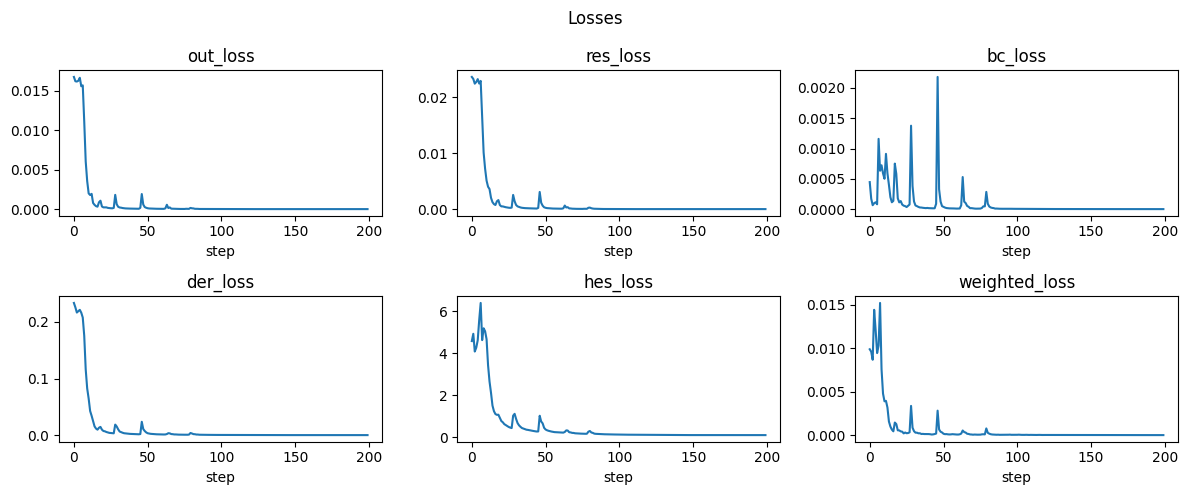


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 30
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Output+Derivative
	EWC: Off
	DWA: Norm1
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 0.8602802753448486
	IC: 1.0
	RES: 0.035579003393650055
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 0.0852857455611229
	DER: 0.01885494403541088
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importance

In [5]:
subkeys = ["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"]
if EWC:
    subkeys.append("ewc_loss")
        
for model_index, show in [(1, False), (2, False), (3, True)]:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["train"],
        subkeys=subkeys,
        figsize=(12, 5),
        legend=False,
        title="Losses",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/losses.png",
        show=show
    )

    if show:
        print_model_info(f"{models_dir}/trial0")

Last bc_loss grad norm: 5.381447772379033e-05
Last distill_out_loss grad norm: 0.0005425959243439138
Last distill_der_loss grad norm: 0.0024549909867346287
Last res_loss grad norm: 0.0018725639674812555
Last weighted_loss grad norm: 3.8312737160595134e-05


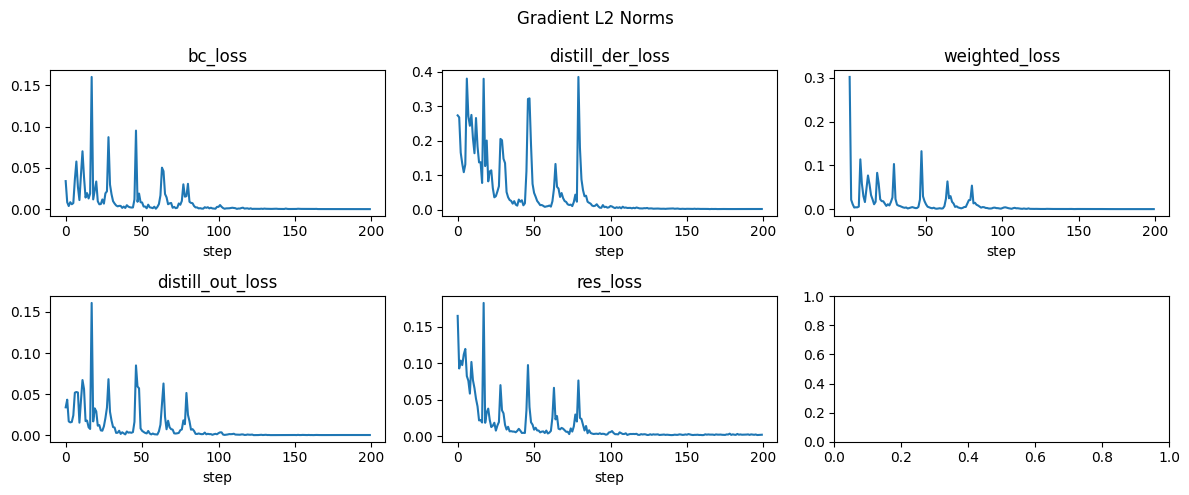

Last value weights res_loss: 0.035579003393650055
Last value weights bc_loss: 0.8602802753448486
Last value weights distill_out_loss: 0.0852857455611229
Last value weights distill_der_loss: 0.01885494403541088


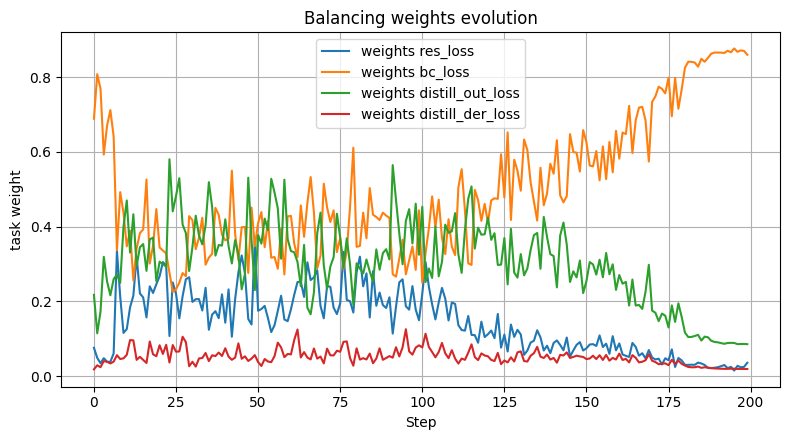

Last value conflicts bc_loss: -0.329181432723999
Last value conflicts distill_out_loss: -0.17478246986865997
Last value conflicts distill_der_loss: 0.17250606417655945


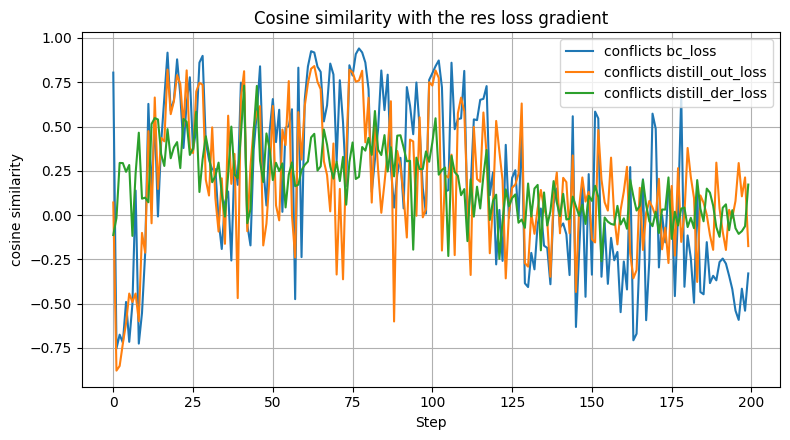

In [6]:
models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom3/models"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

subkeys = ["bc_loss"]
if DISTILL:    
    items = DISTILL_MODE.split("+")
    if "Output" in items:
        subkeys.append("distill_out_loss")
    if "Derivative" in items:
        subkeys.append("distill_der_loss")
    if "Hessian" in items:
        subkeys.append("distill_hes_loss")
if REPLAY:
    subkeys.append("nl_loss")
    subkeys.append("nl_bc_loss")

for subkey in subkeys+["res_loss"]:
    print(f"Last {subkey} grad norm: {models_dict['trial0']['grad_norms'][subkey][-1]}")
print(f"Last weighted_loss grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

if len(subkeys) > 2:
    figsize = (12, 5)
else:
    figsize = (12, 3)
for model_index, show in [(1, False), (2, False), (3, True)]:
    models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=subkeys+["res_loss", "weighted_loss"],
        figsize=figsize,
        legend=False,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png",
        show=show
    )
    
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss"]+subkeys,
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
if EWC:
    subkeys2 = subkeys+["ewc_loss"]
else:
    subkeys2 = subkeys
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=subkeys2,
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

In [7]:
def plot_points_grid(
        dataset: str|TensorDataset,
        labels_idx: list = [1, 2, 3],
        label_names: list = [r"$u^{\theta}$", r"$\nabla_x u^{\theta}$", r"$\nabla_y u^{\theta}$"],
        points_idx: int = 0,
        subtitles: list = ["", "", ""],
        save: bool = False,
        dst_file: str = "points_grid.png",
        show: bool = True,
        cmap: str = "bwr",
        title: str = "",
        figsize: tuple = (10, 2.5),
        vmins: list = [None, None, None],
        vmaxs: list = [None, None, None]
    ) -> tuple:
    """
    Plot the dataset points values in a grid, colored according to the labels values.

    Parameters
    ----------
    dataset : str|TensorDataset
        The dataset filepath/TensorDataset object.
    labels_idx : list
        Labels column indices in the dataset.
    labels_names : list
    points_idx : int
        Spatial coordinates column index in the dataset.
    subtitles : list
    save : bool
        If True, the plot is saved.
    show : bool
        If True, the plot is showed.
    dst_file : str
        Filepath where to save the plot.
    cmap : str
    title : str
    figsize : tuple
    vmins : List[float]
    vmaxs : List[float]
    
    Returns
    -------
    tuple
        vmins, vmaxs
    """
    if type(dataset) is str:
        dataset = torch.load(dataset, weights_only=False)
    points = dataset.tensors[points_idx]
    labelss = [dataset.tensors[i] for i in labels_idx]

    font = {'size': 10}
    matplotlib.rc('font', **font)
    fig = plt.figure(figsize=figsize)
    if len(labels_idx) <= 4:
        gs = GridSpec(1, len(labels_idx), figure=fig)
        axes = [fig.add_subplot(gs[0, i]) for i in range(len(labels_idx))]
    elif len(labels_idx) <= 8:
        ncols = int(np.ceil(len(labels_idx)/2))
        gs = GridSpec(2, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
    else:
        raise ValueError("Too many plots.")

    for ax, labels, label_name, subtitle, vmin, vmax in zip(axes, labelss, label_names, subtitles, vmins, vmaxs):
        ax.set_title(subtitle)
        if vmin is not None and vmax is not None:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap)

        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(label_name)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.plot()

    fig.suptitle(title)
    plt.tight_layout()
    if save:
        plt.savefig(dst_file)
    if show:
        plt.show()
    else:
        plt.close()
    vmins = [torch.min(labels) for labels in labelss]
    vmaxs = [torch.max(labels) for labels in labelss]

In [8]:
if CROSS_THE_RUBICON:
    for model_index in [3]:
        models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models"
        os.makedirs(f"{models_dir}/plots", exist_ok=True)
        if PARAM_INDEX != None:
            datasets = [full_datasets[PARAM_INDEX]]
        else:
            datasets = full_datasets
        best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")
    
        for x_datasets, s in [(datasets, "full_dataset")]:
            os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
            for i, ds in tqdm(enumerate(x_datasets[:3]), total=len(x_datasets[:3])):#total=len(x_datasets)):
                x = ds.datasets[0].tensors[X]
                u = ds.datasets[0].tensors[U]
                du = ds.datasets[0].tensors[DU]
                trues = [x, u, du[:, 0], du[:, 1]]
                trues = TensorDataset(*trues)

                labeled = compute_prediction(model=best_model, dataset=ds.datasets[0])
    
                if PARAM_INDEX is None:
                    j = i
                else:
                    j = PARAM_INDEX
    
                if not os.path.exists(f"{PDE}/data/plots/{s}/true_values{j}.png"):
                    os.makedirs(f"{PDE}/data/plots/{s}", exist_ok=True)
                    true = extract_targets(dataset=ds.datasets[0])    
                    vmins, vmaxs = plot_points_grid(
                        dataset=true,
                        cmap="inferno",
                        save=SAVE_PLOTS,
                        dst_file=f"{PDE}/data/plots/{s}/true_values{j}.png",
                        show=False
                    )
                    vmins = np.array(vmins)
                    vmaxs = np.array(vmaxs)
                    np.save(f"{PDE}/data/plots/{s}/vmins{j}.npy", vmins)
                    np.save(f"{PDE}/data/plots/{s}/vmaxs{j}.npy", vmaxs)
                else:
                    vmins = np.load(f"{PDE}/data/plots/{s}/vmins{j}.npy")
                    vmaxs = np.load(f"{PDE}/data/plots/{s}/vmaxs{j}.npy")
    
                plot_points_grid(
                    dataset=labeled,
                    cmap="inferno",
                    vmins=vmins,
                    vmaxs=vmaxs,
                    save=SAVE_PLOTS,
                    dst_file=f"{models_dir}/plots/{s}/best_model_predictions{j}.png",
                    show=False
                );

                plot_points_grid(
                    dataset=trues,
                    cmap="inferno",
                    label_names=[r"$u$", r"$\nabla_x u$", r"$\nabla_y u$"],
                    vmins=vmins,
                    vmaxs=vmaxs,
                    save=SAVE_PLOTS,
                    dst_file=f"{models_dir}/plots/{s}/true_predictions{j}.png",
                    show=False
                );
    
                differences = compute_prediction_difference(model=best_model, dataset=ds.datasets[0])
                #vmins = len(differences)*[min([t.min() for t in differences.tensors[1:]])]
                #vmaxs = len(differences)*[max([t.max() for t in differences.tensors[1:]])]
                vmin_u = max([t.min() for t in differences.tensors[1]])
                vmin_dux = max([t.min() for t in differences.tensors[2]])
                vmin_duy = max([t.min() for t in differences.tensors[3]])

                vmax_u = max([t.max() for t in differences.tensors[1]])
                vmax_dux = max([t.max() for t in differences.tensors[2]])
                vmax_duy = max([t.max() for t in differences.tensors[3]])

                v_diff_u = max(abs(vmin_u), abs(vmax_u))
                v_diff_dux = max(abs(vmin_dux), abs(vmax_dux))
                v_diff_duy = max(abs(vmin_duy), abs(vmax_duy))

                vmins = [-v_diff_u, -v_diff_dux, -v_diff_duy]
                vmaxs = [v_diff_u, v_diff_dux, v_diff_duy]
                
                plot_points_grid(
                    dataset=differences,
                    vmins=vmins,
                    vmaxs=vmaxs,
                    label_names=[r"$u^{\theta} - u$", r"$\nabla_x u^{\theta} - \nabla_x u$", r"$\nabla_y u^{\theta} - \nabla_y u$"],
                    save=SAVE_PLOTS,
                    dst_file=f"{models_dir}/plots/{s}/differences{j}.png",
                    show=False
                );
    
            print(f"{s} predictions saved.")

100%|██████████| 3/3 [00:19<00:00,  6.50s/it]

full_dataset predictions saved.


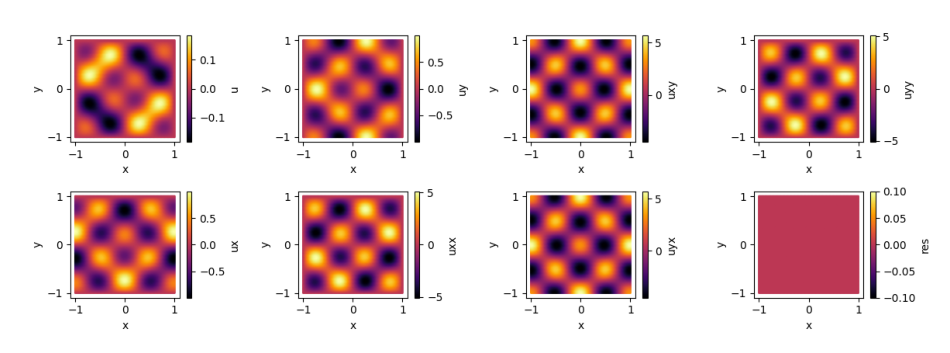

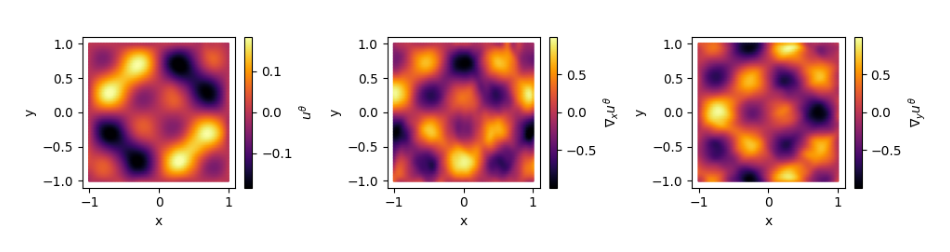

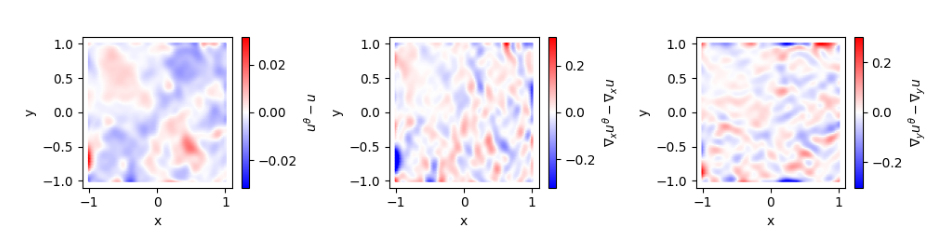

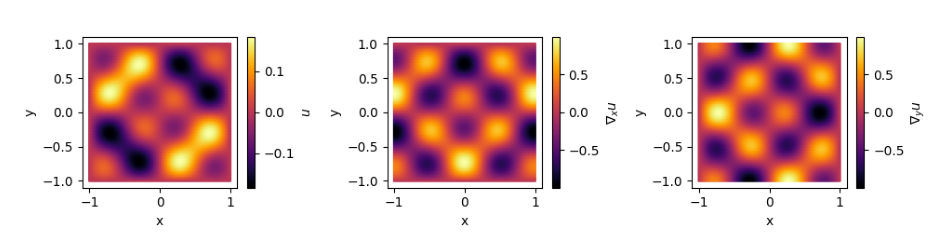

-------------------------------------------


In [9]:
if CROSS_THE_RUBICON:
    model_index = 3
    
    if PARAM_INDEX is None:
        to_show = [0]
    else:
        to_show = [PARAM_INDEX]
    dataset_name = "full_dataset"
    
    models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models"
    dataset_name = "full_dataset"
    
    for i in to_show:
        if PARAM_INDEX is None:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{i}.png")
        else:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{PARAM_INDEX}.png")
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        for img_name in [f"best_model_predictions{i}", f"differences{i}", f"true_predictions{i}"]:
            img = mpimg.imread(f"{models_dir}/plots/{dataset_name}/{img_name}.png")
            plt.figure(figsize=(12, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        print("-------------------------------------------")

Model 1
subset  metric      train           intra_test      
--------------------------------------------------------------------------------
0       out_loss    0.0000808146    0.0000776321    
1       out_loss    0.0000181105    0.0000190756    
2       out_loss    0.0463302471    0.0462254919    
3       out_loss    0.0498397425    0.0474985465    
--------------------------------------------------------------------------------
0       der_loss    0.0027684276    0.0028163770    
1       der_loss    0.0005865717    0.0006097452    
2       der_loss    0.5053501725    0.5048352480    
3       der_loss    0.8772842884    0.8980356455    
--------------------------------------------------------------------------------
0       hes_loss    0.5675220490    0.6077626348    
1       hes_loss    0.1193084195    0.1338478625    
2       hes_loss    30.0121364594   31.0704116821   
3       hes_loss    39.7386703491   37.1410675049   
------------------------------------------------------------

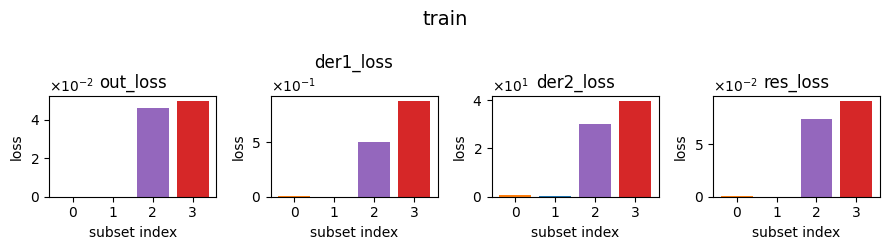

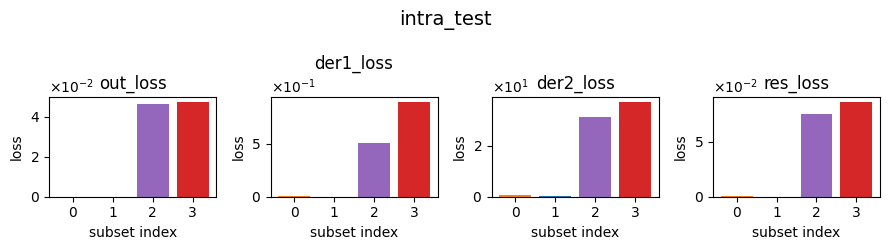

Model 2
subset  metric      train           intra_test      
--------------------------------------------------------------------------------
0       out_loss    0.0007884733    0.0007316813    
1       out_loss    0.0004085990    0.0004155068    
2       out_loss    0.0000432571    0.0000427920    
3       out_loss    0.0816815421    0.0785969943    
--------------------------------------------------------------------------------
0       der_loss    0.0315705314    0.0303497110    
1       der_loss    0.0185403693    0.0184152629    
2       der_loss    0.0018061664    0.0020005144    
3       der_loss    1.1728464365    1.2220635414    
--------------------------------------------------------------------------------
0       hes_loss    6.3243417740    6.0422821045    
1       hes_loss    4.0140714645    4.0747342110    
2       hes_loss    0.4610103369    0.5299401879    
3       hes_loss    92.8600769043   97.0736160278   
------------------------------------------------------------

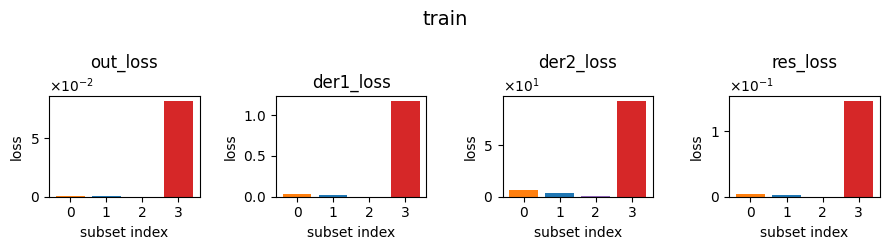

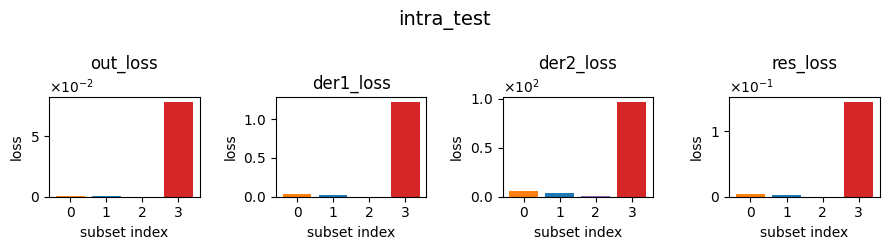

Model 3
subset  metric      train           intra_test      
--------------------------------------------------------------------------------
0       out_loss    0.0156633407    0.0154512189    
1       out_loss    0.0097149769    0.0097584594    
2       out_loss    0.0154033583    0.0153083066    
3       out_loss    0.0037084445    0.0038644189    
--------------------------------------------------------------------------------
0       der_loss    0.3396308422    0.3356435597    
1       der_loss    0.2268070877    0.2309377789    
2       der_loss    0.3619326949    0.3550521731    
3       der_loss    0.0756652430    0.0767451897    
--------------------------------------------------------------------------------
0       hes_loss    60.8021354675   63.1088714600   
1       hes_loss    37.1823158264   39.4175109863   
2       hes_loss    62.3180274963   64.5011291504   
3       hes_loss    6.2789921761    6.4923777580    
------------------------------------------------------------

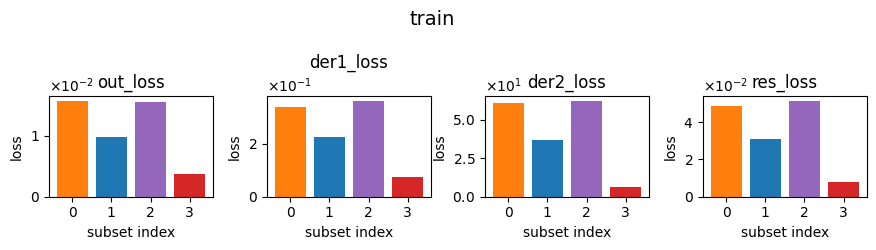

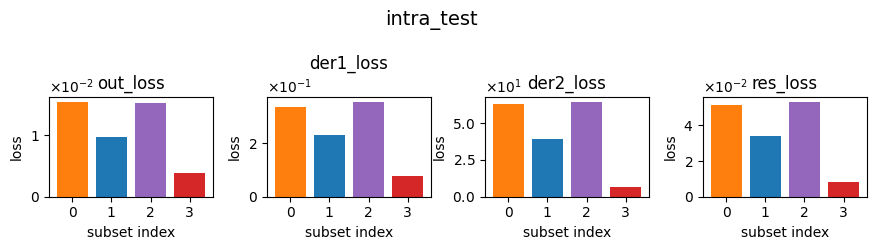

In [9]:
if CROSS_THE_RUBICON:
    subsets = [
        {"x": [0.0, 1.0], "y": [0.0, 1.0]},
        {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
    ]
    
    models_dirs = [f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models" for model_index in [1, 2, 3]]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    
    datasets = [train_data, intra_test_data]
    datasets_names = ["train", "intra_test"]
    
    i = 1
    for model, models_dir in zip(models, models_dirs):
        print(f"Model {i}")
        dst_files = ["train_dataset", "intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dir}/plots/{s}/performance_per_subset.png" for s in dst_files]
    
        lossesss = print_model_performances(
            model=model,
            datasets=datasets,
            datasets_names=datasets_names,
            subsets=subsets
        )
    
        plot_model_performances(
            lossesss=lossesss,
            datasets_names=datasets_names,
            figsize=(9, 2.5),
            save=SAVE_PLOTS,
            dst_files=dst_files
        )
        i += 1

In [10]:
if CROSS_THE_RUBICON:
    subsets = [
        {"x": [0.0, 1.0], "y": [0.0, 1.0]},
        {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
    ]
    
    models_dirs = [
        f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_DOM0}/models2",
        f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom0_{N_EPOCHS_DOM0}/models2"
    ] + [f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models" for model_index in [1, 2, 3]]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = ["Mfull", "M0", "M1", "M2", "M3"]
    
    datasets = [train_data, intra_test_data]
    
    for i, subset in tqdm(enumerate(subsets), total=len(subsets)):
        datasets_names = ["train","intra_test"]
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]
    
        dst_files = ["train_dataset", "intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[-1]}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dirs[-1]}/plots/{s}/models_comparison_subset{i}.png" for s in dst_files]
    
        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(9, 2.5),
            bar_labels=False,
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=False
        )

100%|██████████| 4/4 [00:07<00:00,  1.90s/it]


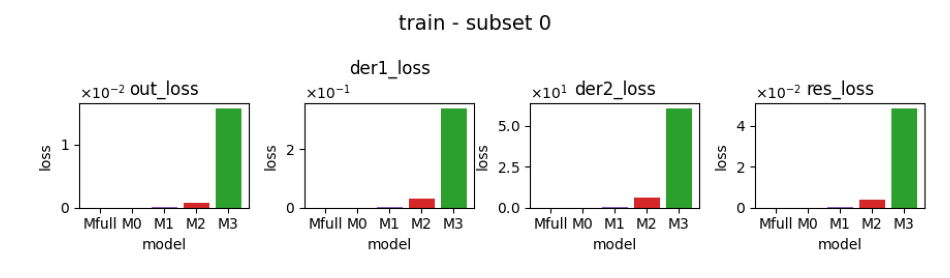

In [11]:
if CROSS_THE_RUBICON:
    subset = 0
    dataset_name = "train_dataset"
    
    models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom3/models"
    img_file = f"{models_dir}/plots/{dataset_name}/models_comparison_subset{subset}.png"
    img = mpimg.imread(img_file)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [12]:
subsets = [
    {"x": [0.0, 1.0], "y": [0.0, 1.0]},
    {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
    {"x": [-1.0, 0.0], "y": [0.0, 1.0]},
    {"x": [-1.0, 1.0], "y": [-1.0, 1.0]}
]

for model_index in [1, 2, 3]:
    models_dirs = [
        f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_DOM0}/models2",
        f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{model_index}/models"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = ["Mfull", f"M{model_index}"]
    
    datasets = [train_data, intra_test_data]
    
    for i, subset in enumerate(subsets):
        datasets_names = ["train", "intra_test"]
        if i != 4:
            datasets_names = [f"{s} - subset {i}" for s in datasets_names]
        else:
            datasets_names = [f"{s} - full domain" for s in datasets_names]
    
        dst_files = ["train_dataset", "intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[-1]}/plots/{s}", exist_ok=True)
        if i != 4:
            dst_files = [f"{models_dirs[-1]}/plots/{s}/full_comparison_subset{i}.png" for s in dst_files]
        else:
            dst_files = [f"{models_dirs[-1]}/plots/{s}/full_comparison_fullDomain.png" for s in dst_files]
    
        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(11, 3),
            bar_labels=True,
            yaxis_visible=True,
            colors=["firebrick", "tab:blue"],
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=False
        )

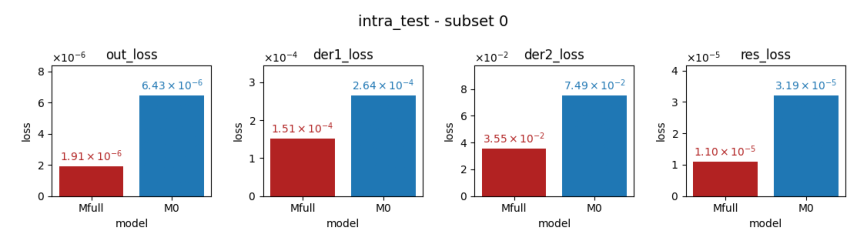

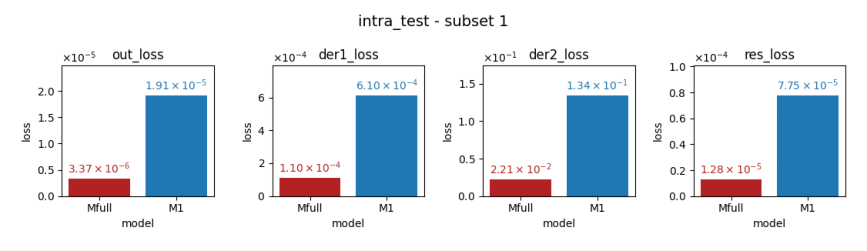

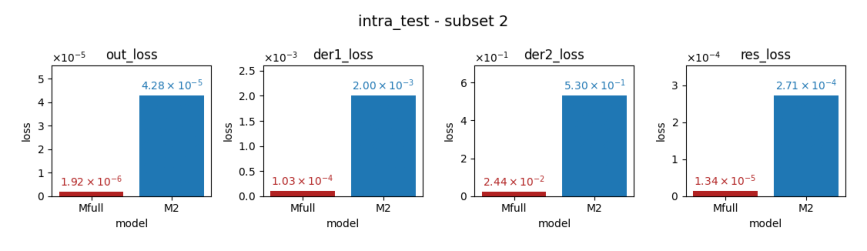

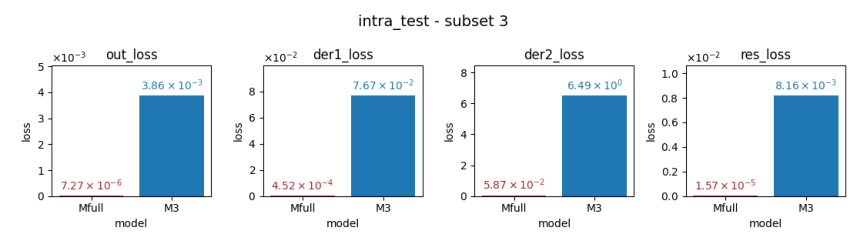

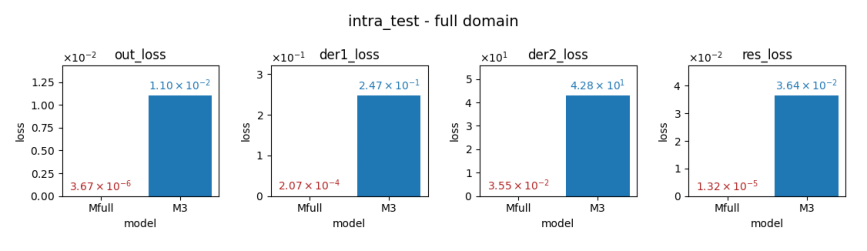

In [13]:
dataset_name = "intra_test_dataset"

models_dir = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/Dom0_{N_EPOCHS_DOM0}/models2"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_subset0.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(11, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

for i in [1, 2, 3]:
    models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom{i}/models"
    img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_subset{i}.png"
    img = mpimg.imread(img_file)
    plt.figure(figsize=(11, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

models_dir = f"./{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd/{FOLDER}/Dom3/models"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_fullDomain.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(11, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
if CLIP_GRAD == False:
    subsets = [{"x": [-1.0, 1.0], "y": [-1.0, 1.0]}]

    models_dirs = [
        f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_GradClip_{BD_MODE}Bd/{FOLDER}/Dom3_{N_EPOCHS}/models",
        f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_NoGradClip_{BD_MODE}Bd{FOLDER}/Dom3_{N_EPOCHS}/models"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = [f"GradClip", f"NoGradClip"]

    datasets = [intra_test_data]

    for i, subset in enumerate(subsets):
        datasets_names = ["intra_test"]
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]

        dst_files = ["intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[0]}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dirs[0]}/plots/{s}/clip_grad_or_not_subset{i}.png" for s in dst_files]

        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(11, 3),
            bar_labels=True,
            yaxis_visible=True,
            colors=["firebrick", "tab:blue"],
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=True
        )

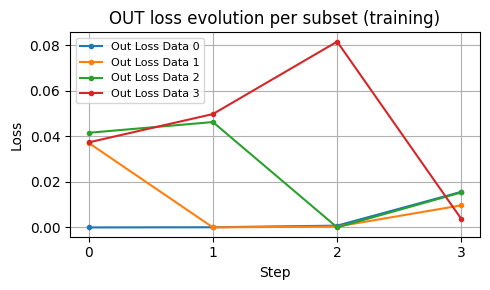

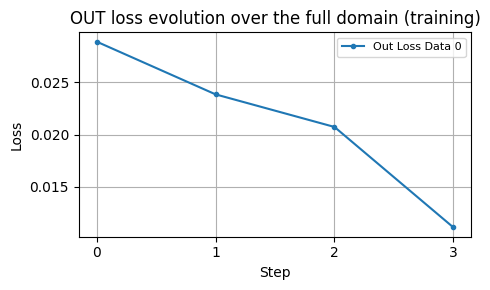

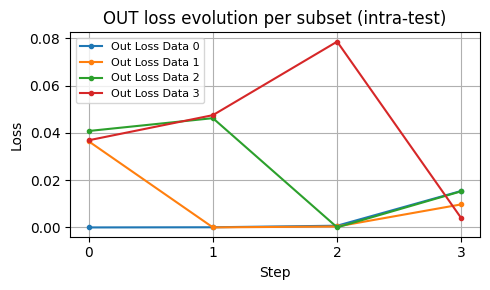

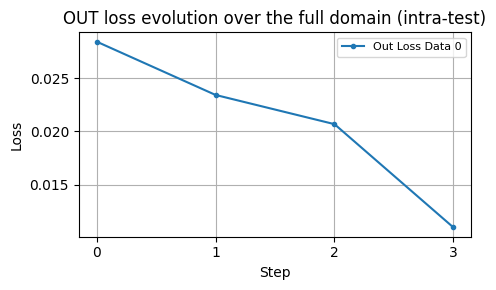

In [15]:
prefix = f"{PDE}/DomainIncrementalLearning/{DIR}/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}_{BD_MODE}Bd"

models = [f"{prefix}/Dom0_{N_EPOCHS_DOM0}/models2/trial0/model.pth"] + \
    [f"{prefix}/{FOLDER}/Dom{i}/models/trial0/model.pth" for i in [1, 2, 3]]
datass = [
    [extract_TensorDataset(
        dataset = prepare_dataset(train_dataset),
        spatial_ranges = subsets[i]
    ) for i in [0, 1, 2, 3]],
    [extract_TensorDataset(prepare_dataset(train_dataset))],
    [extract_TensorDataset(
        dataset = prepare_dataset(intra_test_dataset),
        spatial_ranges = subsets[i]
    ) for i in [0, 1, 2, 3]],
    [extract_TensorDataset(prepare_dataset(intra_test_datasets))]
]
title_start = "OUT loss evolution"
titles = [
    title_start + " per subset (training)",
    title_start + " over the full domain (training)",
    title_start + " per subset (intra-test)",
    title_start + " over the full domain (intra-test)"
    ]
filenames = [
    "train_out_loss_per_subset",
    "train_out_loss_full_domain",
    "intra_test_out_loss_per_subset",
    "intra_test_out_loss_full_domain"
]
plot_dir = f"{prefix}/{FOLDER}/ForgetPlots"
os.makedirs(plot_dir, exist_ok=True)
for datas, title, filename in zip(datass, titles, filenames):
    plot_loss(
        model_sequence=models,
        losses=["out"],
        data_sequence=datas,
        title=title,
        save=SAVE_PLOTS,
        dst_file=f"{plot_dir}/{filename}.png",
        figsize=(5, 3),
        legend_fontsize=8
    )